# Simply Supported Beam Calculation — Implementation Guide

This notebook explains the Python modules implemented for the take-home engineering calculation task.

It covers:

1. Reading values and formulas from `source_workbook.xlsx`
2. The engineering formulas used by `beam_check.py`
3. SI and Imperial unit conversion
4. Input validation and PASS/FAIL metrics
5. Running the production Python module
6. Running `pytest` tests with explicit approximations
7. Simple engineering plots
8. An optional line-of-best-fit demonstration

> **Scope note:** Machine learning is not required by the original task. The line-of-best-fit example below is educational only and is not used to make the engineering PASS/FAIL decision.

## 1. Installation

Install the Python packages used by this notebook:

```bash
pip install openpyxl pandas matplotlib pytest
```

The production calculation module itself uses only the Python standard library.

In [1]:
!pip install openpyxl pandas matplotlib pytest

In [2]:
from pathlib import Path
import sys

# Allow imports from the folder containing beam_check.py
PROJECT_DIR = Path(".").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from beam_check import beam_check

## 2. Reading the Excel Workbook

`openpyxl` is used to inspect workbook values and formulas.

The workbook is read twice:

- `data_only=False` to inspect Excel formulas
- `data_only=True` to inspect cached calculated values

This is useful because formulas are part of the engineering task itself.

In [3]:
from openpyxl import load_workbook

workbook_path = PROJECT_DIR / "Task/source_workbook.xlsx"

wb_formula = load_workbook(workbook_path, data_only=False)
wb_values = load_workbook(workbook_path, data_only=True)

print("Sheets:", wb_formula.sheetnames)

for sheet_name in wb_formula.sheetnames:
    ws = wb_formula[sheet_name]
    print(f"\n--- {sheet_name} ---")
    for row in ws.iter_rows():
        values = [cell.value for cell in row]
        if any(value is not None for value in values):
            print(values)

Sheets: ['Inputs', 'Calculation']

--- Inputs ---
['Input', 'Value', 'Unit']
['Span, L', 6, 'm']
['Uniform load, w', 10, 'kN/m']
['Section modulus, S', 597, 'cm3']
['Second moment of area, I', 8503, 'cm4']
["Young's modulus, E", 200, 'GPa']
['Yield strength, fy', 275, 'MPa']
['Deflection limit ratio, n (limit = L/n)', 360, '-']

--- Calculation ---
['Quantity', 'Value', 'Unit', None, None]
['Max bending moment, M', '=Inputs!B3*Inputs!B2^2/8', 'kN·m', None, 100000]
['Bending stress, sigma', '=B2*1000/Inputs!B4', 'MPa', None, None]
['Utilisation, sigma/fy', '=B3/Inputs!B7', '-', None, None]
['Stress check', '=IF(B4<=1,"PASS","FAIL")', '-', None, None]
['Midspan deflection, delta', '=5*Inputs!B3*Inputs!B2^4/(384*Inputs!B6*Inputs!B5)*E2', 'mm', None, None]
['Deflection limit, L/n', '=Inputs!B2*1000/Inputs!B8', 'mm', None, None]
['Deflection check', '=IF(B6<=B7,"PASS","FAIL")', '-', None, None]


### Expected workbook formulas

The calculation logic identified from the workbook is:

- Maximum bending moment: `M = wL² / 8`
- Bending stress: `σ = M / S`
- Utilisation: `σ / fy`
- Stress result: `PASS` when utilisation `<= 1`
- Midspan deflection: `δ = 5wL⁴ / (384EI)`
- Deflection limit: `L / n`
- Deflection result: `PASS` when `δ <= limit`

The workbook also contains an undocumented `100000` multiplier in its deflection calculation. The production Python code deliberately avoids copying this as a magic number and instead performs explicit unit conversions.

## 3. Engineering formulas and metric scores

### Maximum bending moment

For a simply supported beam carrying a full-span uniformly distributed load:

\[
M_{max} = \frac{wL^2}{8}
\]

### Bending stress

\[
\sigma = \frac{M}{S}
\]

### Utilisation

\[
U = \frac{\sigma}{f_y}
\]

The stress metric is:

- `PASS` if `U <= 1`
- `FAIL` if `U > 1`

### Maximum midspan deflection

\[
\delta_{max} = \frac{5wL^4}{384EI}
\]

### Allowable deflection

\[
\delta_{limit} = \frac{L}{n}
\]

The deflection metric is:

- `PASS` if `delta_max <= delta_limit`
- `FAIL` otherwise

## 4. Unit conversion strategy

The workbook-facing SI inputs are:

| Quantity | Input unit | Internal unit |
|---|---|---|
| Span | m | m |
| Uniform load | kN/m | N/m |
| Section modulus | cm³ | m³ |
| Second moment of area | cm⁴ | m⁴ |
| Young's modulus | GPa | Pa |
| Yield strength | MPa | Pa |

Imperial input mode accepts:

- ft
- kip/ft
- in³
- in⁴
- ksi

Conversions happen at the input boundary. The engineering equations then use SI units internally.

In [4]:
# Explicit workbook-facing SI conversions
kn_per_m_to_n_per_m = 1_000.0
cm3_to_m3 = 1e-6
cm4_to_m4 = 1e-8
gpa_to_pa = 1e9
mpa_to_pa = 1e6

# Imperial conversions used by the module
ft_to_m = 0.3048
kip_to_n = 4448.2216152605
inch_to_m = 0.0254
in3_to_m3 = inch_to_m ** 3
in4_to_m4 = inch_to_m ** 4
ksi_to_pa = kip_to_n / inch_to_m ** 2

print("1 ft =", ft_to_m, "m")
print("1 kip =", kip_to_n, "N")
print("1 in^3 =", in3_to_m3, "m^3")
print("1 in^4 =", in4_to_m4, "m^4")
print("1 ksi =", ksi_to_pa, "Pa")

1 ft = 0.3048 m
1 kip = 4448.2216152605 N
1 in^3 = 1.6387064e-05 m^3
1 in^4 = 4.162314255999999e-07 m^4
1 ksi = 6894757.293168361 Pa


## 5. How conversion is implemented in Python

For SI workbook inputs:

```python
L_m = span
w_n_per_m = uniform_load * 1000
S_m3 = section_modulus * 1e-6
I_m4 = second_moment_of_area * 1e-8
E_pa = youngs_modulus * 1e9
fy_pa = yield_strength * 1e6
```

For Imperial inputs, each value is converted to the same SI base-unit representation before the formulas are evaluated.

## 6. How to implement conversions in Excel

If the original workbook is extended to support Imperial input directly, explicit conversion cells are preferable to hidden multipliers.

Example conversion formulas:

```text
Span_m              = Span_ft * 0.3048
Load_N_per_m        = Load_kip_per_ft * 4448.2216152605 / 0.3048
SectionModulus_m3   = SectionModulus_in3 * (0.0254^3)
SecondMoment_m4     = SecondMoment_in4 * (0.0254^4)
YoungsModulus_Pa    = YoungsModulus_ksi * 6894757.293168
YieldStrength_Pa    = YieldStrength_ksi * 6894757.293168
```

Then use these converted SI cells in the engineering equations.

This approach is clearer and safer than an unlabeled compound multiplier such as `100000`.

## 7. Running the production module

The public function is `beam_check()`.

The pre-filled workbook case is:

In [5]:
result = beam_check(
    span=6.0,
    uniform_load=10.0,
    section_modulus=597.0,
    second_moment_of_area=8503.0,
    youngs_modulus=200.0,
    yield_strength=275.0,
    deflection_limit_ratio=360.0,
    input_units="si",
)

result

BeamCheckResult(maximum_bending_moment_kn_m=45.0, bending_stress_mpa=75.37688442211056, utilisation=0.27409776153494747, midspan_deflection_mm=9.922968364106785, deflection_limit_mm=16.666666666666668, stress_result='PASS', deflection_result='PASS')

## 8. Running the tests

From the project directory:

```bash
pip install pytest
pytest -v
```

The tests use `pytest.approx` because floating-point calculations should generally be compared using explicit numerical tolerances rather than exact equality.

Test categories include:

- Workbook regression test
- SI/Imperial equivalence
- Invalid zero/negative inputs
- Stress boundary behaviour

## 9. Simple engineering plot — bending moment versus span

For fixed load `w`, the maximum bending moment follows:

\[
M_{max} \propto L^2
\]

The following plot visualises that relationship.

In [6]:
conda install matplotlib kiwisolver numpy pandas

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI packages with conda
  using the conda-pypi beta. Get started:
    https://docs.conda.io/projects/conda/en/stable/new-features.html



In [7]:
conda update -n base -c defaults conda

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install matplotlib

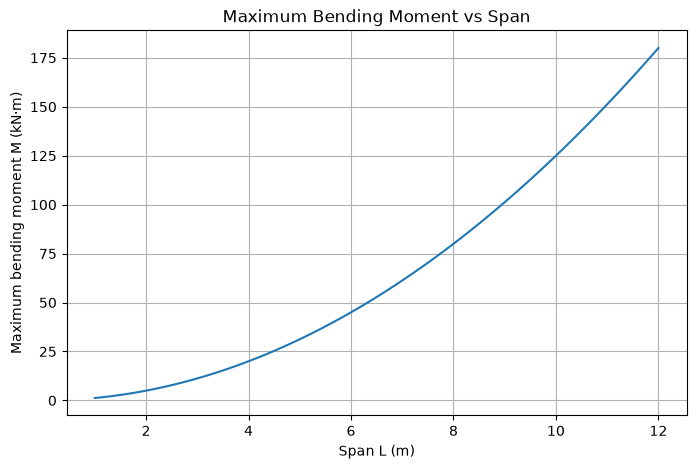

In [9]:
import numpy as np
import matplotlib.pyplot as plt

spans_m = np.linspace(1, 12, 100)
uniform_load_kn_per_m = 10.0
moments_kn_m = uniform_load_kn_per_m * spans_m**2 / 8.0

plt.figure(figsize=(8, 5))
plt.plot(spans_m, moments_kn_m)
plt.xlabel("Span L (m)")
plt.ylabel("Maximum bending moment M (kN·m)")
plt.title("Maximum Bending Moment vs Span")
plt.grid(True)
plt.show()

## 10. Simple engineering plot — deflection versus span

For fixed `w`, `E`, and `I`:

\[
\delta_{max} \propto L^4
\]

This explains why deflection becomes increasingly important as span increases.

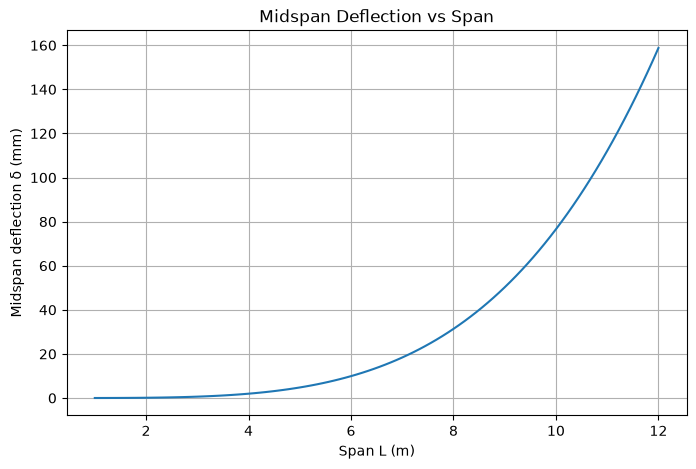

In [10]:
E_pa = 200e9
I_m4 = 8503e-8
load_n_per_m = 10e3

deflection_mm = (
    5 * load_n_per_m * spans_m**4 / (384 * E_pa * I_m4)
) * 1000

plt.figure(figsize=(8, 5))
plt.plot(spans_m, deflection_mm)
plt.xlabel("Span L (m)")
plt.ylabel("Midspan deflection δ (mm)")
plt.title("Midspan Deflection vs Span")
plt.grid(True)
plt.show()

## 11. Optional line of best fit

This is an **illustrative regression exercise only**. It is not part of the required engineering calculation and should not replace the analytical beam equations.

For the generated data below, a straight line is fitted to the relationship between span and bending moment. Because the true relationship is quadratic, the straight-line fit is intentionally imperfect.

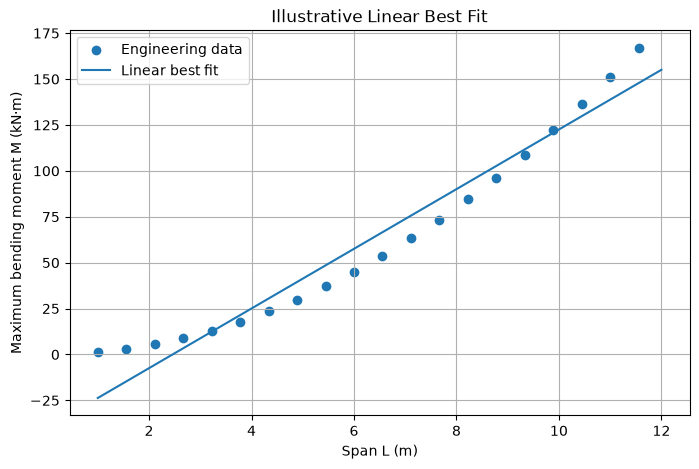

Best-fit equation:
M ≈ 16.2500L + -39.9537


In [11]:
# Illustrative line-of-best-fit demonstration; not used by beam_check().
coefficients = np.polyfit(spans_m, moments_kn_m, 1)
best_fit_moments = np.polyval(coefficients, spans_m)

plt.figure(figsize=(8, 5))
plt.scatter(spans_m[::5], moments_kn_m[::5], label="Engineering data")
plt.plot(spans_m, best_fit_moments, label="Linear best fit")
plt.xlabel("Span L (m)")
plt.ylabel("Maximum bending moment M (kN·m)")
plt.title("Illustrative Linear Best Fit")
plt.grid(True)
plt.legend()
plt.show()

print("Best-fit equation:")
print(f"M ≈ {coefficients[0]:.4f}L + {coefficients[1]:.4f}")

## 12. References

### Source workbook
- `source_workbook.xlsx` supplied with this take-home task.

### Unit conversions
- NIST, *Guide to the SI, Appendix B.8: Factors for Units Listed Alphabetically*.
- NIST lists, among other conversions, `1 ft = 0.3048 m`, `1 kip = 4.448222 × 10³ N`, `1 ksi = 6.894757 × 10⁶ Pa`, and conversions for powers of inches. citeturn0search0turn0search1

### Beam equations
- A checked engineering reference should be retained in the final `VV.md` for the governing equations. One web reference used for cross-checking the simply supported full-span UDL case gives `M_max = wL²/8` and `δ_max = 5wL⁴/(384EI)`.

### Important submission note
For the final take-home submission, the references in `VV.md` should be explicit and independently checkable. This notebook is supporting documentation and is not a substitute for the required three deliverables.